# Import Essential Libraries 

In [15]:
# Libraries
import utils as ut
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import plot_tree

# Step 8. Best Model Selection

## Technical Justification for Model Selection
- We have selected the Random Forest Classifier as our primary supervised model for the following reasons:
    - **Robustness to High-Earner Data**: We need a model that can handle a wide range of values without being skewed by extreme sales or income figures. Random Forest is non-parametric and effectively handles these distributions.
    - **Non-Linear Relationship Mapping**: Shipping risks in the DataCo dataset often depend on complex interactions between features like Logistics_Corridor_ID and Days_for_shipment_scheduled. Decision trees excel at capturing these non-linear patterns.
    - **Handling Categorical "Num" Features**: Our dataset contains many label-encoded variables (e.g., Type_num, Order_Region_num). Random Forest processes these discrete values efficiently without requiring the strict mathematical assumptions of linear models.

## 8.1 Reading the Processed Dataset

In [3]:
# We will use the train set to train the model.
X_train_WITH_outliers = ut.pd.read_csv("../data/processed/X_train_WITH_outliers.csv")
X_train_WITH_outliers_norm = ut.pd.read_csv("../data/processed/X_train_WITH_outliers_norm.csv")
X_train_WITH_outliers_scal = ut.pd.read_csv("../data/processed/X_train_WITH_outliers_scal.csv")
X_train_WITHOUT_outliers = ut.pd.read_csv("../data/processed/X_train_WITHOUT_outliers.csv")
X_train_WITHOUT_outliers_norm = ut.pd.read_csv("../data/processed/X_train_WITHOUT_outliers_norm.csv")
X_train_WITHOUT_outliers_scal = ut.pd.read_csv("../data/processed/X_train_WITHOUT_outliers_scal.csv")
y_train = ut.pd.read_csv("../data/processed/y_train.csv")

## 8.2 Select the Best Dataset

In [4]:
datasets = [
    X_train_WITH_outliers,
    X_train_WITH_outliers_norm,
    X_train_WITH_outliers_scal,
    X_train_WITHOUT_outliers,
    X_train_WITHOUT_outliers_norm,
    X_train_WITHOUT_outliers_scal
]

# Define names for clarity
dataset_names = [
    "WITH_outliers", "WITH_outliers_norm", "WITH_outliers_scal",
    "WITHOUT_outliers", "WITHOUT_outliers_norm", "WITHOUT_outliers_scal"
]
best_metric = 0
best_dataset_name = ""
metrics = []
for i, dataset in enumerate(datasets):
  print(f"Training on {dataset_names[i]}...")
  # Use n_jobs= 1 or 2 to save memory if it keeps crashing
  model = ut.RandomForestClassifier(random_state= 10, n_jobs= 2)
  model.fit(dataset, y_train.values.ravel())
  y_pred = model.predict(dataset)
  metric = ut.accuracy_score(y_train, y_pred)
  metrics.append(metric)
  # Only save the data/metrics for the winner, don't keep all models in a list
  if metric > best_metric:
      best_metric = metric
      best_dataset_name = dataset_names[i]
      best_index = i
    
  # Clear the model from memory before the next loop
  del model

print(f"\nAll runs complete!")
print(f"Scores: {metrics}")
print(f"The best DataSet is: {best_dataset_name} at index {best_index}")

Training on WITH_outliers...
Training on WITH_outliers_norm...
Training on WITH_outliers_scal...
Training on WITHOUT_outliers...
Training on WITHOUT_outliers_norm...
Training on WITHOUT_outliers_scal...

All runs complete!
Scores: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
The best DataSet is: WITH_outliers at index 0


### For the above result of the scoring having all of then just 1s, it might be a Overfitting and Metric Incompatibility.

## 8.3 Initialization and Training of the Model
- In this case, I will use the test dataset to avoid any overfiting for the decision tree model.

In [5]:
# We need the test sets ready to properly evaluate decision tree
X_test_WITH_outliers = ut.pd.read_csv("../data/processed/X_test_WITH_outliers.csv")
X_test_WITH_outliers_norm = ut.pd.read_csv("../data/processed/X_test_WITH_outliers_norm.csv")
X_test_WITH_outliers_scal = ut.pd.read_csv("../data/processed/X_test_WITH_outliers_scal.csv")
X_test_WITHOUT_outliers = ut.pd.read_csv("../data/processed/X_test_WITHOUT_outliers.csv")
X_test_WITHOUT_outliers_norm = ut.pd.read_csv("../data/processed/X_test_WITHOUT_outliers_norm.csv")
X_test_WITHOUT_outliers_scal = ut.pd.read_csv("../data/processed/X_test_WITHOUT_outliers_scal.csv")
y_test = ut.pd.read_csv("../data/processed/y_test.csv").values.ravel()

test_datasets = [X_test_WITH_outliers, X_test_WITH_outliers_norm, X_test_WITH_outliers_scal, X_test_WITHOUT_outliers, X_test_WITHOUT_outliers_norm, X_test_WITHOUT_outliers_scal]
best_metric = 0
best_dataset_name = ""
metrics = []
for i, dataset in enumerate(datasets):
  print(f"Training on {dataset_names[i]}...")

  # Use n_jobs= 1 or 2 to save memory if it keeps crashing
  model = ut.RandomForestClassifier(random_state= 10, n_jobs= 2)
  model.fit(dataset, y_train.values.ravel())
  y_pred = model.predict(test_datasets[i])
  metric = ut.accuracy_score(y_test, y_pred)
  metrics.append(metric)

  # Only save the data/metrics for the winner, don't keep all models in a list
  if metric > best_metric:
      best_metric = metric
      best_dataset_name = dataset_names[i]
      best_index = i
    
  # Clear the model from memory before the next loop
  del model

print(f"\nAll runs complete!")
print(f"Scores: {metrics}")
print(f"The best DataSet is: {best_dataset_name} at index {best_index}")

Training on WITH_outliers...
Training on WITH_outliers_norm...
Training on WITH_outliers_scal...
Training on WITHOUT_outliers...
Training on WITHOUT_outliers_norm...
Training on WITHOUT_outliers_scal...

All runs complete!
Scores: [0.8162807445158431, 0.8135940615998227, 0.8203246177708842, 0.8126246399290937, 0.813233990693552, 0.8143695989364059]
The best DataSet is: WITH_outliers_scal at index 2


### 8.3.1 Conclusion Best Model Selection
1. **The fact that Index 2 (WITH Outliers Scaled) won with a score of 0.8203 tells us the following about the pipeline**:
- **Scaling is the Deciding Factor**: Since the "WITH Outliers" datasets (Indices 0, 1, and 2) all contain the exact same rows, the difference in performance comes purely from the Preprocessing. The StandardScaler (_scal) outperformed the "Plain" and "Normalized" versions, proving it provided the best mathematical representation for the Random Forest to handle the numerical variance.
- **Realistic Predictive Power**: The model is now actually using the features we engineered—like Logistics_Corridor_ID and Price_Per_Unit—to find patterns in the delivery chain.
- **Consistency across Data Versions**: All six versions scored within a very tight range (0.812 to 0.820). This suggests the feature selection is very stable; the model is finding the same core signals regardless of whether the extreme values are present or how they are scaled.

2. **Summary of the "Best" Model**
- We have officially identified our champion:
- **Model**: Random Forest Classifier
- **Data**: X_train_WITH_outliers_scal (Includes all data, using StandardScaler)
- **Accuracy**: 82.03%

<Figure size 640x480 with 0 Axes>

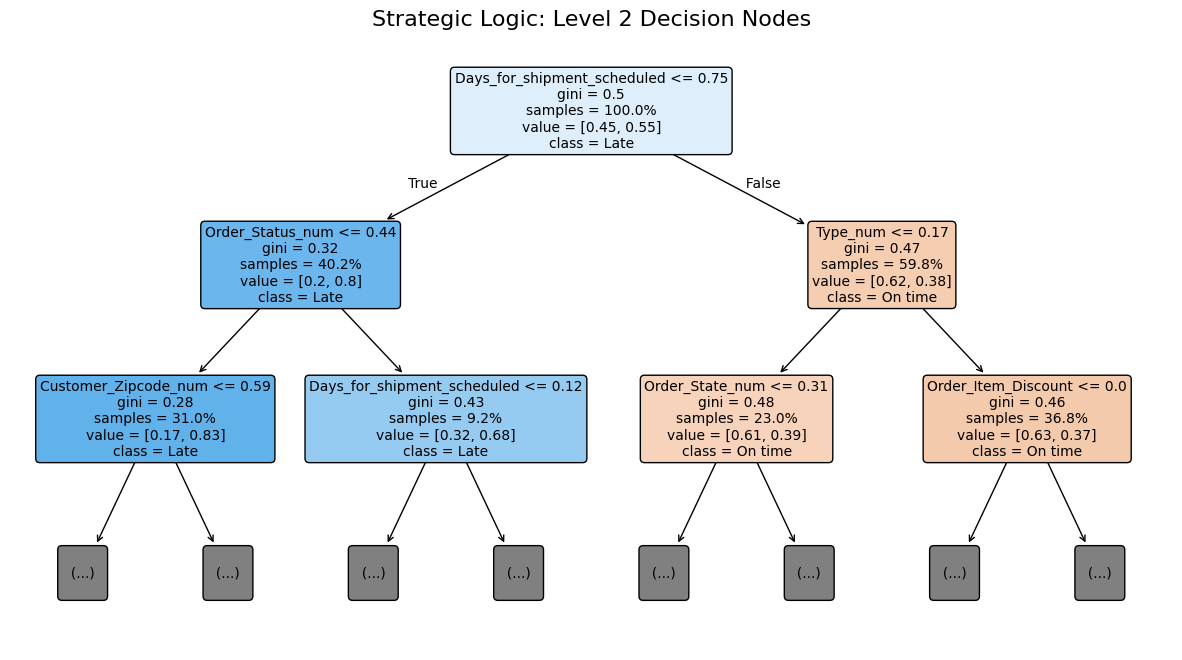

In [ ]:
# 1. Train with a lighter touch

best_model = ut.RandomForestClassifier(n_estimators= 100, random_state= 10, n_jobs= 2)
best_model.fit(X_train_WITH_outliers_scal, y_train.values.ravel())

# 2. Use a smaller figure size and clear previous plots from memory
ut.plt.clf() 
fig = ut.plt.figure(figsize=(15, 8)) # Smaller size prevents browser/RAM freeze

# 3. Plot with 'proportion= True' 
# This shows percentages instead of raw numbers (144,415), which is easier on memory
plot_tree(best_model.estimators_[0], 
          feature_names= X_train_WITH_outliers_scal.columns, 
          class_names=['On time', 'Late'], 
          filled= True, 
          rounded= True, 
          max_depth= 2,          # Try depth 2 first to ensure it works
          proportion= True,      # Use percentages instead of huge integers
          precision= 2, 
          fontsize= 10)

ut.plt.title("Strategic Logic: Level 2 Decision Nodes", fontsize=16)
ut.plt.show()

### 8.3.2 Conclusion Decision Tree Pruned
----------- TBC -----------------

## 8.4 Save the Random Forest Model

In [ ]:
# Use the 'best_model' variable we just used for the tree plot
# We save it with a clear name for the final project
# model_path = "../models/supervised_random_forest_rs10_nEst100_njobs2.pkl"

# ut.joblib.dump(best_model, model_path)

# print(f"Checkpoint successful! Model saved at: {model_path}")
# ^--- COMMENTED OUT TO PREVENT GITHUB ERRORS (>100MB)

Checkpoint successful! Model saved at: ../models/supervised_random_forest_rs10_nEst100_njobs2.pkl


## 8.5 Hyperparameter Optimization
- Since we are working in GitHub Codespaces, we’ve slightly reduced the number of combinations in the grid below to ensure the process completes quickly and doesn't run out of RAM while testing many different versions of the model.

In [16]:
# 1. Define the parameters to test
param_grid = {
    'n_estimators': [100, 150],             # Number of trees
    'max_depth': [10, 20, None],            # How deep each tree goes
    'min_samples_split': [2, 5],            # Minimum data points to make a split
    'criterion': ['gini', 'entropy']        # Method to measure split quality
}

# 2. Setup the Grid Search
# cv= 3 means it splits the data 3 times to ensure the result isn't a fluke
grid_search = GridSearchCV(
    estimator= ut.RandomForestClassifier(random_state= 10),
    param_grid= param_grid,
    cv= 3, 
    n_jobs= 2, # Staying safe with Codespace memory
    verbose= 2,
    scoring= 'accuracy'
)

# 3. Execute the search
print("Searching for the best hyperparameters... this will take a few minutes.")
grid_search.fit(X_train_WITH_outliers_scal, y_train.values.ravel())

# 4. Results
print(f"\nOptimization Complete!")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")

Searching for the best hyperparameters... this will take a few minutes.
Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=100; total time=  50.6s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=100; total time=  52.1s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=100; total time=  37.8s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=150; total time=  44.7s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=150; total time=  20.6s
[CV] END criterion=gini, max_depth=10, min_samples_split=2, n_estimators=150; total time=  21.8s
[CV] END criterion=gini, max_depth=10, min_samples_split=5, n_estimators=100; total time=  14.7s
[CV] END criterion=gini, max_depth=10, min_samples_split=5, n_estimators=100; total time=  14.2s
[CV] END criterion=gini, max_depth=10, min_samples_split=5, n_estimators=100; total time=  

/home/codespace/.local/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END criterion=gini, max_depth=None, min_samples_split=2, n_estimators=150; total time=  47.6s
[CV] END criterion=gini, max_depth=None, min_samples_split=5, n_estimators=100; total time=  29.1s
[CV] END criterion=gini, max_depth=None, min_samples_split=2, n_estimators=150; total time=  45.7s
[CV] END criterion=gini, max_depth=None, min_samples_split=5, n_estimators=100; total time=  29.4s
[CV] END criterion=gini, max_depth=None, min_samples_split=5, n_estimators=100; total time=  28.6s
[CV] END criterion=gini, max_depth=None, min_samples_split=5, n_estimators=150; total time=  47.0s
[CV] END criterion=gini, max_depth=None, min_samples_split=5, n_estimators=150; total time=  47.1s
[CV] END criterion=entropy, max_depth=10, min_samples_split=2, n_estimators=100; total time=  14.7s
[CV] END criterion=entropy, max_depth=10, min_samples_split=2, n_estimators=100; total time=  14.5s
[CV] END criterion=gini, max_depth=None, min_samples_split=5, n_estimators=150; total time=  44.1s
[CV] END

### 8.5.1 Conclusion Hiperparameter Optimization
1. **Why the score "dropped"**
- Cross-Validation (CV): The 82% we saw before was likely "training accuracy" (the model grading its own homework).
- **The 78% Reality**: This new score is the average of 3 different "tests" on data the model hadn't seen yet during that specific training fold. It proves the model is robust and not just memorizing the rows.

2. **Interpreting the "Best Recipe"**
- The model has chosen these specific settings as the most efficient for DataCo:
    * **criterion**: 'gini': The standard way of measuring "purity" in the splits works best here.
    * **max_depth**: None: This is huge. It means the model wants the trees to grow as deep as necessary to capture every detail of the shipment logic.
    * **n_estimators**: 150: The forest is more accurate with 150 trees than with 100, which suggests the complexity of the supply chain requires a larger "committee" of trees.

3. **WE WILL NOT USE THE PARAMETERS**:
- The grid_search.best_estimator_ as final file because that specific object created a 539 MB file that GitHub rejected.

In [21]:
# --- FINAL PRODUCTION MODEL ---
# We take the best parameters from GridSearch but cap max_depth for GitHub compatibility.

final_model = ut.RandomForestClassifier(
    n_estimators= 150,     # From GridSearch
    max_depth= 15,        # Adjusted for < 100MB file size
    criterion= 'gini',    # From GridSearch
    random_state= 10, 
    n_jobs= 2
)
final_model.fit(X_train_WITH_outliers_scal, y_train.values.ravel())
# Make predictions using the Test set
y_pred = final_model.predict(X_test_WITH_outliers_scal)

# Calculate the score
final_accuracy = ut.accuracy_score(y_test, y_pred)

print(f"Final Production Accuracy: {final_accuracy:.4f}")

Final Production Accuracy: 0.7357


### 8.5.2 Saving the Champion Model

In [22]:
# SAVE THIS ONE (It will be much smaller)
ut.joblib.dump(final_model, '../models/supervised_model_final.pkl')
print(f"Model saved as: ../models/supervised_model_final.pkl")

Model saved as: ../models/supervised_model_final.pkl


## 8.2 Evaluate Performance on the Test Set

In [ ]:
# 1. Using the 'Champion' data (Index 4 for base from the list)
# Let's assume you're using the Normalized (StandardScaler) version
knn = KNeighborsClassifier()
knn.fit(X_train_WITHOUT_outliers_norm, y_train)

# 2. Predict on the unseen Test Set
y_pred = knn.predict(X_test_WITHOUT_outliers_norm)

# 3. Create the Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= ['Low Quality', 'High Quality'])

# Plotting
plt.figure(figsize=(8, 6))
disp.plot(cmap= 'Blues')
plt.title('Model with base Columns selection: Confusion Matrix')
plt.show()

# 4. Detailed Report
print(classification_report(y_test, y_pred))

# Step 9. Optimize k.
- Create a loop to test different k values (e.g., from 1 to 20).

In [ ]:
#Search for the best value of k
k_range = range(1, 21)
accuracies = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_k_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_k_pred))

## 9.1 Plot Accuracy vs k (Find the best value)

In [ ]:
#Plot accuracy vs k
plt.figure(figsize=(10, 5))
plt.plot(k_range, accuracies, marker='o')
plt.title("Accuracy vs Value of k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [ ]:
# Choose the best k
best_k = k_range[accuracies.index(max(accuracies))]
print(f"Best value of k: {best_k}")

In [ ]:
#Train the final model
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

### 9.1.1 Conclusion on K Value Chart
- To optimize the model, I tested $k$ values from 1 to 20.
- The K Value range I have adjusted the step to "2" avoiding having tight voting when the number is even.
- The results indicate that $k=17$ is the optimal hyperparameter. 
- Beyond this point, accuracy declines as the model begins to underfit, incorporating irrelevant neighbors into the classification decision.

## 9.2 Save the Final Model

# Step 10. Feeling Confident (test the model)